<a href="https://colab.research.google.com/github/Catz94/Python-for-Data-Science-Case-Study/blob/main/Python_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**3. Data Preparation & Exploration**

3.1 Dataset Structure & Data Health Audit

In [2]:
import pandas as pd
import numpy as np

df_water_raw = pd.read_csv('water_consumption.csv')
df_ipi_raw = pd.read_csv('ipi.csv')

print("=== Water Consumption Dataset Audit ===")
print("Shape:", df_water_raw.shape)
print("Missing Values:\n", df_water_raw.isnull().sum())
print("Duplicates:", df_water_raw.duplicated().sum())

print("\n=== Industrial Production Index Dataset Audit ===")
print("Shape:", df_ipi_raw.shape)
print("Missing Values:\n", df_ipi_raw.isnull().sum())
print("Duplicates:", df_ipi_raw.duplicated().sum())

=== Water Consumption Dataset Audit ===
Shape: (600, 4)
Missing Values:
 state     0
sector    0
date      0
value     0
dtype: int64
Duplicates: 0

=== Industrial Production Index Dataset Audit ===
Shape: (398, 4)
Missing Values:
 series      0
date        0
index       0
index_sa    0
dtype: int64
Duplicates: 0


3.2 Restructuring, Feature Engineering & Merging

In [3]:

df_water_raw['date'] = pd.to_datetime(df_water_raw['date'])
df_water_raw['year'] = df_water_raw['date'].dt.year

df_ipi_raw['date'] = pd.to_datetime(df_ipi_raw['date'])
df_ipi_raw['year'] = df_ipi_raw['date'].dt.year

df_water_pivot = df_water_raw.pivot(
    index=['year', 'state'],
    columns='sector',
    values='value'
).reset_index()

df_water_pivot['total_water'] = df_water_pivot['domestic'] + df_water_pivot['nondomestic']
df_water_pivot['nondomestic_pct'] = (df_water_pivot['nondomestic'] / df_water_pivot['total_water']) * 100

df_ipi_abs = df_ipi_raw[df_ipi_raw['series'] == 'abs'].copy()
annual_ipi = df_ipi_abs[(df_ipi_abs['year'] >= 2015) & (df_ipi_abs['year'] <= 2022)] \
    .groupby('year')['index'].mean().reset_index()
annual_ipi.rename(columns={'index': 'annual_ipi'}, inplace=True)

national_water = df_water_pivot[df_water_pivot['state'] == 'Malaysia'].copy()
merged_national = pd.merge(national_water, annual_ipi, on='year', how='inner')

print("\n=== Prepared Merged National Dataset (2015–2022) ===")
print(merged_national[['year', 'domestic', 'nondomestic', 'total_water', 'nondomestic_pct', 'annual_ipi']].to_string(index=False))


=== Prepared Merged National Dataset (2015–2022) ===
 year  domestic  nondomestic  total_water  nondomestic_pct  annual_ipi
 2015      6378         4067        10445        38.937291  100.000083
 2016      6490         4249        10739        39.566068  104.124667
 2017      6447         4341        10788        40.239155  108.722417
 2018      6605         4476        11081        40.393466  112.159667
 2019      6811         4688        11499        40.768763  114.886250
 2020      7179         4298        11477        37.448811  110.204500
 2021      7540         4173        11713        35.627081  118.321583
 2022      7353         4433        11786        37.612422  126.249000


**4.Findings & Discussion**

In [4]:

states_2022 = df_water_pivot[
    (df_water_pivot['state'] != 'Malaysia') & (df_water_pivot['year'] == 2022)
].sort_values(by='nondomestic', ascending=False)

states_2003 = df_water_pivot[
    (df_water_pivot['state'] != 'Malaysia') & (df_water_pivot['year'] == 2003)
][['state', 'nondomestic']].rename(columns={'nondomestic': 'nd_2003'})

growth_analysis = pd.merge(states_2003, states_2022[['state', 'nondomestic']].rename(columns={'nondomestic': 'nd_2022'}), on='state')
growth_analysis['net_change_mld'] = growth_analysis['nd_2022'] - growth_analysis['nd_2003']
growth_analysis['growth_pct'] = ((growth_analysis['nd_2022'] - growth_analysis['nd_2003']) / growth_analysis['nd_2003']) * 100
growth_analysis = growth_analysis.sort_values(by='nd_2022', ascending=False)

pearson_r = merged_national['nondomestic'].corr(merged_national['annual_ipi'])

print("=== Operation 1: 2022 State Non-Domestic Consumption Ranking ===")
print(states_2022[['state', 'nondomestic', 'domestic', 'total_water', 'nondomestic_pct']].to_string(index=False))

print("\n=== Operation 2: Two-Decade Growth Analysis (2003 vs 2022) ===")
print(growth_analysis[['state', 'nd_2003', 'nd_2022', 'net_change_mld', 'growth_pct']].to_string(index=False))

print(f"\n=== Operation 3: Pearson Correlation Coefficient ===")
print(f"r(National Non-Domestic Water, Annual IPI) = {pearson_r:.4f}")

=== Operation 1: 2022 State Non-Domestic Consumption Ranking ===
          state  nondomestic  domestic  total_water  nondomestic_pct
       Selangor         1350      2230         3580        37.709497
          Johor          536       867         1403        38.203849
        Sarawak          463       602         1065        43.474178
   Pulau Pinang          334       534          868        38.479263
          Perak          289       699          988        29.251012
         Pahang          283       385          668        42.365269
          Sabah          238       394          632        37.658228
Negeri Sembilan          231       307          538        42.936803
          Kedah          217       560          777        27.927928
         Melaka          190       228          418        45.454545
     Terengganu          173       286          459        37.690632
       Kelantan           77       162          239        32.217573
    W.P. Labuan           33        19

**5.Data Visualisations & Interpretation**

5.1. Figure 1: State Comparison Bar Chart (2022)

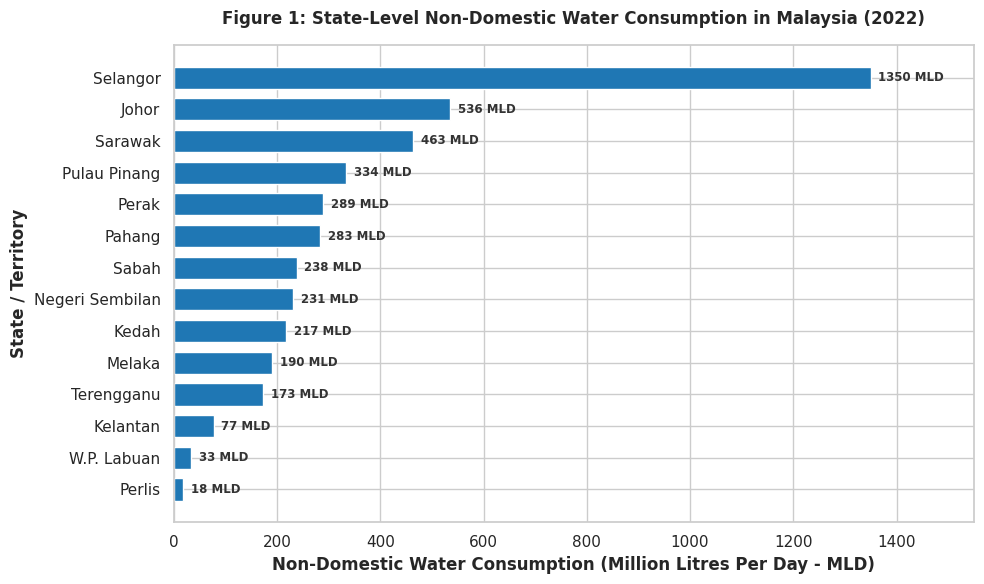

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
bars = plt.barh(
    states_2022['state'][::-1],
    states_2022['nondomestic'][::-1],
    color='#1f77b4',
    height=0.7
)
plt.title('Figure 1: State-Level Non-Domestic Water Consumption in Malaysia (2022)', fontweight='bold', pad=15)
plt.xlabel('Non-Domestic Water Consumption (Million Litres Per Day - MLD)', fontweight='bold')
plt.ylabel('State / Territory', fontweight='bold')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 15, bar.get_y() + bar.get_height()/2, f'{int(width)} MLD', ha='left', va='center', fontsize=8.5, fontweight='bold', color='#333333')

plt.xlim(0, 1550)
plt.tight_layout()
plt.savefig('fig1_state_water_2022.png', dpi=300)
plt.show()

5.2. Figure 2: State Trajectory Multi-Line Chart (2003–2022)

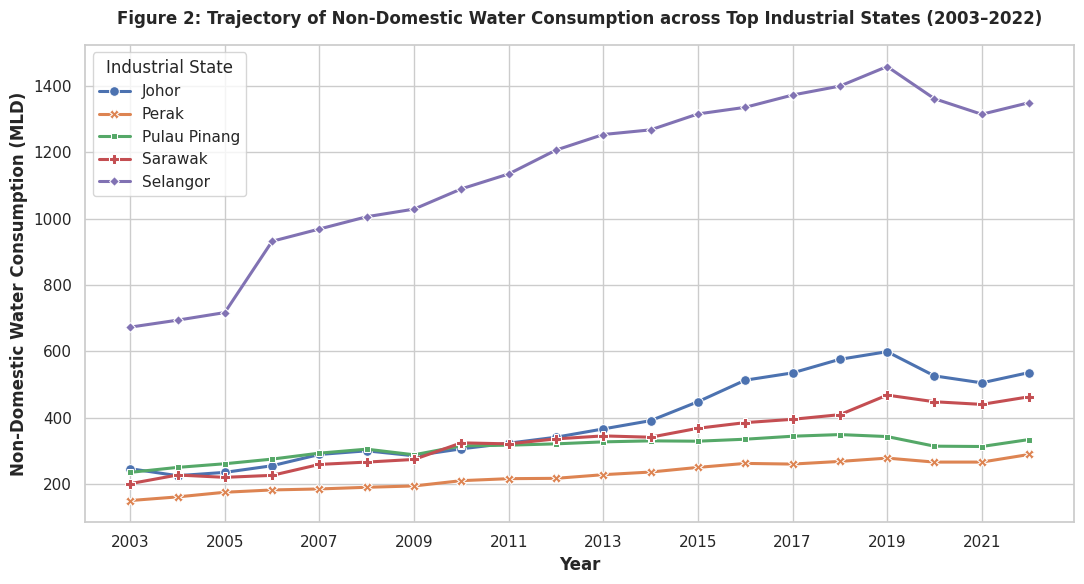

In [6]:
top_states = ['Selangor', 'Johor', 'Sarawak', 'Pulau Pinang', 'Perak']
df_top = df_water_pivot[(df_water_pivot['state'].isin(top_states)) & (df_water_pivot['year'] >= 2003) & (df_water_pivot['year'] <= 2022)]

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=df_top,
    x='year',
    y='nondomestic',
    hue='state',
    style='state',
    markers=True,
    dashes=False,
    linewidth=2.2,
    markersize=7
)
plt.title('Figure 2: Trajectory of Non-Domestic Water Consumption across Top Industrial States (2003–2022)', fontweight='bold', pad=15)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Non-Domestic Water Consumption (MLD)', fontweight='bold')
plt.xticks(range(2003, 2023, 2))
plt.legend(title='Industrial State', loc='upper left')
plt.tight_layout()
plt.savefig('fig2_water_trends_2003_2022.png', dpi=300)
plt.show()

5.3 Figure 3: Macro-Coupling Dual-Axis Combination Chart (2015–2022)

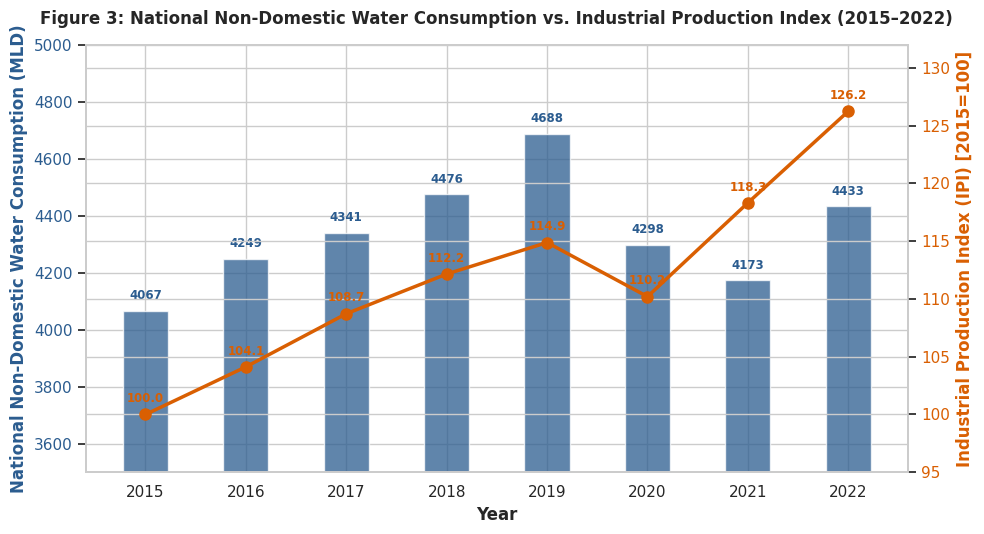

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 5.5))
color1 = '#2b5c8f'
color2 = '#d95f02'
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('National Non-Domestic Water Consumption (MLD)', color=color1, fontweight='bold')
bars3 = ax1.bar(
    merged_national['year'],
    merged_national['nondomestic'],
    color=color1,
    alpha=0.75,
    width=0.45,
    label='Non-Domestic Water (MLD)'
)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(3500, 5000)
for bar in bars3:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 30, f'{int(yval)}', ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=color1)
ax2 = ax1.twinx()
ax2.set_ylabel('Industrial Production Index (IPI) [2015=100]', color=color2, fontweight='bold')
line3 = ax2.plot(
    merged_national['year'],
    merged_national['annual_ipi'],
    color=color2,
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Annual IPI Index'
)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(95, 132)

for i, txt in enumerate(merged_national['annual_ipi']):
    ax2.annotate(f'{txt:.1f}', (merged_national['year'][i], txt + 0.8), ha='center', va='bottom', fontsize=8.5, fontweight='bold', color=color2)

plt.title('Figure 3: National Non-Domestic Water Consumption vs. Industrial Production Index (2015–2022)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig3_water_vs_ipi.png', dpi=300)
plt.show()